In [1]:
import os
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
INPUT_PATH = Path("Dataset/input")
PRODUCT_PATH = Path("Dataset/product_properties.parquet")

assert INPUT_PATH.exists(), f"Missing folder: {INPUT_PATH}"
assert PRODUCT_PATH.exists(), f"Missing file: {PRODUCT_PATH}"

print("INPUT_PATH:", INPUT_PATH.resolve())
print("PRODUCT_PATH:", PRODUCT_PATH.resolve())

INPUT_PATH: /home/sagemaker-user/Dataset/input
PRODUCT_PATH: /home/sagemaker-user/Dataset/product_properties.parquet


In [3]:
clients = np.load(INPUT_PATH / "relevant_clients.npy")

product_buy = pd.read_parquet(INPUT_PATH / "product_buy.parquet")
add_to_cart = pd.read_parquet(INPUT_PATH / "add_to_cart.parquet")
page_visit = pd.read_parquet(INPUT_PATH / "page_visit.parquet")
search_query = pd.read_parquet(INPUT_PATH / "search_query.parquet")
product_props = pd.read_parquet(PRODUCT_PATH)

print(f"Loaded clients: {len(clients):,}")
print("product_buy:", product_buy.shape)
print("add_to_cart:", add_to_cart.shape)
print("page_visit:", page_visit.shape)
print("search_query:", search_query.shape)
print("product_props:", product_props.shape)

Loaded clients: 1,000,000
product_buy: (1775394, 3)
add_to_cart: (5674064, 3)
page_visit: (156032014, 3)
search_query: (10218831, 3)
product_props: (1260365, 4)


In [4]:
print("product_buy columns:", product_buy.columns.tolist())
print("add_to_cart columns:", add_to_cart.columns.tolist())
print("page_visit columns:", page_visit.columns.tolist())
print("search_query columns:", search_query.columns.tolist())
print("product_props columns:", product_props.columns.tolist())

product_buy columns: ['client_id', 'timestamp', 'sku']
add_to_cart columns: ['client_id', 'timestamp', 'sku']
page_visit columns: ['client_id', 'timestamp', 'url']
search_query columns: ['client_id', 'timestamp', 'query']
product_props columns: ['sku', 'category', 'price', 'name']


In [5]:
def detect_time_col(df):
    for c in ["timestamp", "event_time", "time", "datetime"]:
        if c in df.columns:
            return c
    return None

buy_time_col = detect_time_col(product_buy)
cart_time_col = detect_time_col(add_to_cart)
visit_time_col = detect_time_col(page_visit)
search_time_col = detect_time_col(search_query)

print("buy_time_col:", buy_time_col)
print("cart_time_col:", cart_time_col)
print("visit_time_col:", visit_time_col)
print("search_time_col:", search_time_col)

buy_time_col: timestamp
cart_time_col: timestamp
visit_time_col: timestamp
search_time_col: timestamp


In [6]:
sample_size = 8000
sample_clients = clients[:sample_size]
sample_clients_set = set(sample_clients)

product_buy = product_buy[product_buy["client_id"].isin(sample_clients_set)].copy()
add_to_cart = add_to_cart[add_to_cart["client_id"].isin(sample_clients_set)].copy()
page_visit = page_visit[page_visit["client_id"].isin(sample_clients_set)].copy()
search_query = search_query[search_query["client_id"].isin(sample_clients_set)].copy()

print("Filtered product_buy:", product_buy.shape)
print("Filtered add_to_cart:", add_to_cart.shape)
print("Filtered page_visit:", page_visit.shape)
print("Filtered search_query:", search_query.shape)

Filtered product_buy: (10357, 3)
Filtered add_to_cart: (21501, 3)
Filtered page_visit: (334706, 3)
Filtered search_query: (37653, 3)


In [7]:
if buy_time_col is None:
    raise ValueError("No timestamp column found in product_buy.")

product_buy[buy_time_col] = pd.to_datetime(product_buy[buy_time_col])

global_split_time = product_buy[buy_time_col].quantile(0.80)
print("Global split time:", global_split_time)

past_buys = product_buy[product_buy[buy_time_col] <= global_split_time].copy()
future_buys = product_buy[product_buy[buy_time_col] > global_split_time].copy()

print("past_buys:", past_buys.shape)
print("future_buys:", future_buys.shape)

Global split time: 2022-10-18 07:41:50
past_buys: (8285, 3)
future_buys: (2072, 3)


In [8]:
if visit_time_col is not None:
    page_visit[visit_time_col] = pd.to_datetime(page_visit[visit_time_col])
    page_visit = page_visit[page_visit[visit_time_col] <= global_split_time].copy()

if search_time_col is not None:
    search_query[search_time_col] = pd.to_datetime(search_query[search_time_col])
    search_query = search_query[search_query[search_time_col] <= global_split_time].copy()

print("page_visit after time filter:", page_visit.shape)
print("search_query after time filter:", search_query.shape)

page_visit after time filter: (273239, 3)
search_query after time filter: (30863, 3)


In [9]:
needed_cols = ["sku"]
if "category" in product_props.columns:
    needed_cols.append("category")
if "price" in product_props.columns:
    needed_cols.append("price")

product_small = product_props[needed_cols].drop_duplicates(subset=["sku"]).copy()

past_buys = past_buys[["client_id", "sku", buy_time_col]].copy()
past_buys = past_buys.merge(product_small, on="sku", how="left")

print("past_buys after merge:", past_buys.shape)
print("product_small:", product_small.shape)

past_buys after merge: (8285, 5)
product_small: (1260365, 3)


In [10]:
past_buy_counts = past_buys.groupby("client_id").size().rename("past_total_buys")
past_unique_skus = past_buys.groupby("client_id")["sku"].nunique().rename("past_unique_skus")

if "price" in past_buys.columns:
    past_avg_price = past_buys.groupby("client_id")["price"].mean().rename("past_avg_price")
else:
    past_avg_price = pd.Series(dtype=float, name="past_avg_price")

past_page_visits = page_visit.groupby("client_id").size().rename("past_page_visits")
past_searches = search_query.groupby("client_id").size().rename("past_searches")

if "category" in past_buys.columns:
    cat_counts = (
        past_buys.groupby(["client_id", "category"])
        .size()
        .unstack(fill_value=0)
    )
    cat_counts.columns = [f"past_buy_cat_{c}" for c in cat_counts.columns]
else:
    cat_counts = pd.DataFrame()

baseline_df = pd.DataFrame(index=pd.Index(sample_clients, name="client_id"))
baseline_df = baseline_df.join(past_buy_counts, how="left")
baseline_df = baseline_df.join(past_unique_skus, how="left")
baseline_df = baseline_df.join(past_avg_price, how="left")
baseline_df = baseline_df.join(past_page_visits, how="left")
baseline_df = baseline_df.join(past_searches, how="left")

if not cat_counts.empty:
    baseline_df = baseline_df.join(cat_counts, how="left")

baseline_df = baseline_df.fillna(0).reset_index()
print(baseline_df.shape)
baseline_df.head()

(8000, 1714)


,client_id,past_total_buys,past_unique_skus,past_avg_price,past_page_visits,past_searches,past_buy_cat_0,past_buy_cat_1,past_buy_cat_4,past_buy_cat_5,...,past_buy_cat_6947,past_buy_cat_6950,past_buy_cat_6956,past_buy_cat_6957,past_buy_cat_6959,past_buy_cat_6962,past_buy_cat_6974,past_buy_cat_6977,past_buy_cat_6980,past_buy_cat_6986
0,9473050,0.0,0.0,0.0,12.0,16.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3993147,1.0,1.0,59.0,13.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,18854120,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,587758,0.0,0.0,0.0,70.0,13.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,14810719,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
future_buy_flag = (
    future_buys.groupby("client_id")
    .size()
    .gt(0)
    .astype(int)
    .rename("target")
)

baseline_df = baseline_df.merge(future_buy_flag, on="client_id", how="left")
baseline_df["target"] = baseline_df["target"].fillna(0).astype(int)

print("Target mean:", baseline_df["target"].mean())
baseline_df[["client_id", "target"]].head()

Target mean: 0.111625


,client_id,target
0,9473050,0
1,3993147,0
2,18854120,0
3,587758,0
4,14810719,0


In [12]:
X = baseline_df.drop(columns=["client_id", "target"]).copy()
y = baseline_df["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Positive rate:", y.mean())

Train shape: (6000, 1713)
Test shape: (2000, 1713)
Positive rate: 0.111625


In [13]:
baseline_results = {}

lr = LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict_proba(X_test_scaled)[:, 1]
baseline_results["Logistic Regression"] = roc_auc_score(y_test, lr_pred)

lr_logloss = log_loss(y_test, lr_pred)

print("Logistic Regression AUROC:", baseline_results["Logistic Regression"])
print("Logistic Regression Log Loss:", lr_logloss)

Logistic Regression AUROC: 0.6152456273610736
Logistic Regression Log Loss: 0.6594607343895432


In [14]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict_proba(X_test)[:, 1]
baseline_results["Random Forest"] = roc_auc_score(y_test, rf_pred)

rf_logloss = log_loss(y_test, rf_pred)

print("Random Forest AUROC:", baseline_results["Random Forest"])
print("Random Forest Log Loss:", rf_logloss)

Random Forest AUROC: 0.7216084447259576
Random Forest Log Loss: 0.3131416634515161


In [15]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.30),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

mlp = MLPClassifier(X_train.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)

train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

mlp_losses = []

epochs = 15
for epoch in range(epochs):
    mlp.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = mlp(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(xb)

    avg_loss = total_loss / len(train_loader.dataset)
    mlp_losses.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{epochs} - loss: {avg_loss:.4f}")

mlp.eval()
with torch.no_grad():
    logits = mlp(X_test_t.to(device))
    probs = torch.sigmoid(logits).cpu().numpy().ravel()

baseline_results["ANN / MLP"] = roc_auc_score(y_test, probs)

print("ANN / MLP AUROC:", baseline_results["ANN / MLP"])
print("ANN final training loss:", mlp_losses[-1])

Epoch 01/15 - loss: 0.5064
Epoch 02/15 - loss: 0.3528
Epoch 03/15 - loss: 0.3067
Epoch 04/15 - loss: 0.2828
Epoch 05/15 - loss: 0.2702
Epoch 06/15 - loss: 0.2656
Epoch 07/15 - loss: 0.2615
Epoch 08/15 - loss: 0.2570
Epoch 09/15 - loss: 0.2556
Epoch 10/15 - loss: 0.2531
Epoch 11/15 - loss: 0.2508
Epoch 12/15 - loss: 0.2516
Epoch 13/15 - loss: 0.2473
Epoch 14/15 - loss: 0.2488
Epoch 15/15 - loss: 0.2462
ANN / MLP AUROC: 0.6259314963749556
ANN final training loss: 0.2462024869521459


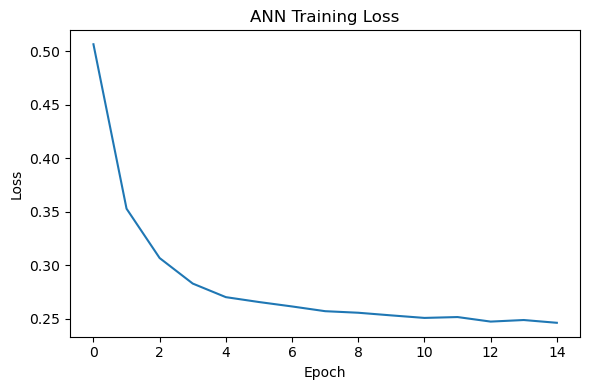

In [16]:
plt.figure(figsize=(6,4))
plt.plot(mlp_losses)
plt.title("ANN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

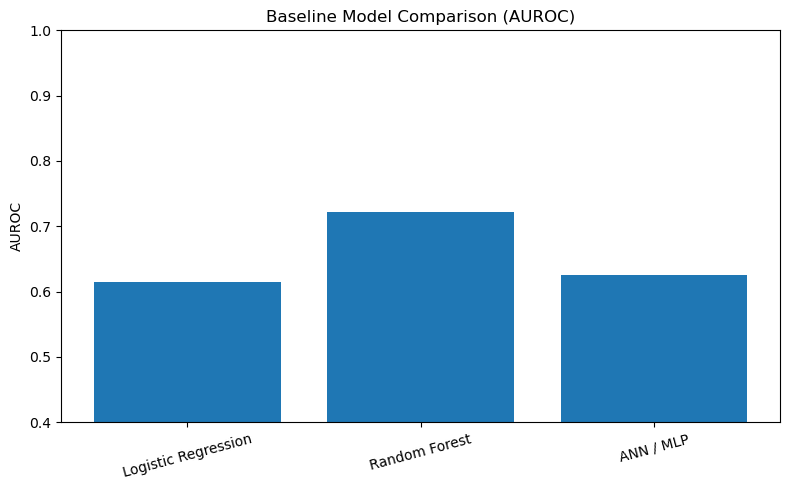

In [17]:
plt.figure(figsize=(8,5))
plt.bar(
    ["Logistic Regression", "Random Forest", "ANN / MLP"],
    [
        baseline_results["Logistic Regression"],
        baseline_results["Random Forest"],
        baseline_results["ANN / MLP"]
    ]
)
plt.title("Baseline Model Comparison (AUROC)")
plt.ylabel("AUROC")
plt.ylim(0.4, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [18]:
seq_df = product_buy.copy()
seq_df = seq_df[["client_id", "sku", buy_time_col]].drop_duplicates().copy()
seq_df[buy_time_col] = pd.to_datetime(seq_df[buy_time_col])
seq_df = seq_df.sort_values(["client_id", buy_time_col])

unique_users = seq_df["client_id"].unique()
unique_items = seq_df["sku"].unique()

user2idx_seq = {u: i for i, u in enumerate(unique_users)}
item2idx_seq = {it: i+1 for i, it in enumerate(unique_items)}  # 0 for padding

seq_df["user_idx"] = seq_df["client_id"].map(user2idx_seq)
seq_df["item_idx"] = seq_df["sku"].map(item2idx_seq)

num_users_seq = len(user2idx_seq)
num_items_seq = len(item2idx_seq) + 1

print("num_users_seq:", num_users_seq)
print("num_items_seq:", num_items_seq)

num_users_seq: 4122
num_items_seq: 7610


In [19]:
user_sequences = (
    seq_df.groupby("user_idx")["item_idx"]
    .apply(list)
    .to_dict()
)

user_sequences = {u: seq for u, seq in user_sequences.items() if len(seq) >= 3}
print("Usable sequences:", len(user_sequences))

Usable sequences: 747


In [20]:
MAX_LEN = 10

X_seq = []
y_seq = []

for u, items in user_sequences.items():
    for i in range(1, len(items)):
        hist = items[:i]
        target = items[i]

        hist = hist[-MAX_LEN:]
        padded = [0] * (MAX_LEN - len(hist)) + hist

        X_seq.append(padded)
        y_seq.append(target)

X_seq = np.array(X_seq, dtype=np.int64)
y_seq = np.array(y_seq, dtype=np.int64)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (3866, 10)
y_seq shape: (3866,)


In [21]:
X_seq_train, X_seq_test, y_seq_train, y_seq_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=SEED
)

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_seq_ds = SequenceDataset(X_seq_train, y_seq_train)
test_seq_ds = SequenceDataset(X_seq_test, y_seq_test)

train_seq_loader = DataLoader(train_seq_ds, batch_size=256, shuffle=True)
test_seq_loader = DataLoader(test_seq_ds, batch_size=256, shuffle=False)

In [22]:
class LSTMNextItem(nn.Module):
    def __init__(self, num_items, emb_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(num_items, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_items)

    def forward(self, x):
        emb = self.embedding(x)
        out, (h_n, c_n) = self.lstm(emb)
        final_hidden = h_n[-1]
        logits = self.fc(final_hidden)
        return logits

lstm_model = LSTMNextItem(num_items=num_items_seq, emb_dim=64, hidden_dim=128).to(device)
criterion_lstm = nn.CrossEntropyLoss()
optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

In [23]:
lstm_losses = []

epochs = 10
for epoch in range(epochs):
    lstm_model.train()
    total_loss = 0.0

    for xb, yb in train_seq_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer_lstm.zero_grad()
        logits = lstm_model(xb)
        loss = criterion_lstm(logits, yb)
        loss.backward()
        optimizer_lstm.step()

        total_loss += loss.item() * len(xb)

    avg_loss = total_loss / len(train_seq_loader.dataset)
    lstm_losses.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{epochs} - loss: {avg_loss:.4f}")

Epoch 01/10 - loss: 8.9412
Epoch 02/10 - loss: 8.8352
Epoch 03/10 - loss: 8.4965
Epoch 04/10 - loss: 8.1284
Epoch 05/10 - loss: 7.8825
Epoch 06/10 - loss: 7.7375
Epoch 07/10 - loss: 7.5869
Epoch 08/10 - loss: 7.4194
Epoch 09/10 - loss: 7.2330
Epoch 10/10 - loss: 7.0237


In [24]:
def hit_rate_at_k(model, loader, k=10):
    model.eval()
    hits = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            topk = torch.topk(logits, k=k, dim=1).indices
            hits += (topk == yb.unsqueeze(1)).any(dim=1).sum().item()
            total += len(xb)

    return hits / total

lstm_hit10 = hit_rate_at_k(lstm_model, test_seq_loader, k=10)
print("LSTM Hit@10:", lstm_hit10)
print("LSTM final training loss:", lstm_losses[-1])

LSTM Hit@10: 0.046511627906976744
LSTM final training loss: 7.023666115349971


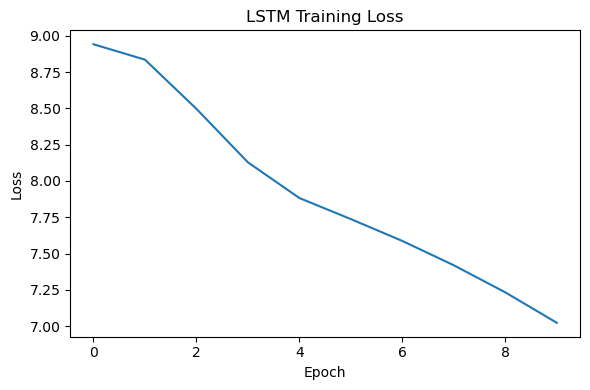

In [25]:
plt.figure(figsize=(6,4))
plt.plot(lstm_losses)
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [26]:
interaction_parts = []

buy_df = product_buy[["client_id", "sku", buy_time_col]].copy()
buy_df["event_weight"] = 3.0
buy_df["event_type"] = "buy"
interaction_parts.append(buy_df)

if "sku" in add_to_cart.columns:
    cart_df = add_to_cart[["client_id", "sku", cart_time_col]].copy()
    cart_df["event_weight"] = 2.0
    cart_df["event_type"] = "add_to_cart"
    interaction_parts.append(cart_df)

if "sku" in page_visit.columns and visit_time_col is not None:
    visit_df = page_visit[["client_id", "sku", visit_time_col]].copy()
    visit_df["event_weight"] = 1.0
    visit_df["event_type"] = "page_visit"
    interaction_parts.append(visit_df)
else:
    print("page_visit skipped for recommender because sku or timestamp not available.")

interactions = pd.concat(interaction_parts, ignore_index=True)
interactions.head()

page_visit skipped for recommender because sku or timestamp not available.


,client_id,sku,timestamp,event_weight,event_type
0,15760815,464559,2022-06-23 04:43:25,3.0,buy
1,10291172,30851,2022-06-23 05:29:30,3.0,buy
2,10291172,693837,2022-06-23 05:29:30,3.0,buy
3,6568726,647018,2022-06-23 05:47:30,3.0,buy
4,7033493,611243,2022-06-23 06:09:15,3.0,buy


In [27]:
interactions = interactions.rename(columns={
    buy_time_col: "event_time"
})

if cart_time_col is not None and cart_time_col in interactions.columns:
    interactions = interactions.rename(columns={cart_time_col: "event_time"})
if visit_time_col is not None and visit_time_col in interactions.columns:
    interactions = interactions.rename(columns={visit_time_col: "event_time"})

interactions["event_time"] = pd.to_datetime(interactions["event_time"])

agg_interactions = (
    interactions.groupby(["client_id", "sku"], as_index=False)
    .agg(
        interaction_weight=("event_weight", "sum"),
        last_time=("event_time", "max")
    )
)

print("Aggregated interactions:", agg_interactions.shape)
agg_interactions.head()

Aggregated interactions: (18672, 4)


,client_id,sku,interaction_weight,last_time
0,617,1383449,3.0,2022-08-22 16:09:40
1,617,1394975,3.0,2022-08-22 16:09:40
2,617,1413617,3.0,2022-08-22 16:09:40
3,1601,234831,5.0,2022-09-05 15:51:30
4,1601,685600,5.0,2022-09-05 15:51:30


In [28]:
user_counts = agg_interactions["client_id"].value_counts()
item_counts = agg_interactions["sku"].value_counts()

active_users = user_counts[user_counts >= 3].index
active_items = item_counts[item_counts >= 5].index

agg_interactions = agg_interactions[
    agg_interactions["client_id"].isin(active_users) &
    agg_interactions["sku"].isin(active_items)
].copy()

print("After filtering:", agg_interactions.shape)
print("Users:", agg_interactions["client_id"].nunique())
print("Items:", agg_interactions["sku"].nunique())

After filtering: (398, 4)
Users: 260
Items: 76


In [29]:
user2idx = {u: i for i, u in enumerate(agg_interactions["client_id"].unique())}
item2idx = {it: i for i, it in enumerate(agg_interactions["sku"].unique())}
idx2item = {i: it for it, i in item2idx.items()}

agg_interactions["user_idx"] = agg_interactions["client_id"].map(user2idx)
agg_interactions["item_idx"] = agg_interactions["sku"].map(item2idx)

num_users = len(user2idx)
num_items = len(item2idx)

print("num_users:", num_users)
print("num_items:", num_items)

num_users: 260
num_items: 76


In [30]:
train_df_list = []
test_pairs = []
user_train_items = defaultdict(set)

for user_idx, group in agg_interactions.groupby("user_idx"):
    group = group.sort_values("last_time")

    if len(group) < 2:
        continue

    test_row = group.iloc[-1]
    train_group = group.iloc[:-1]

    for _, row in train_group.iterrows():
        train_df_list.append((user_idx, int(row["item_idx"]), float(row["interaction_weight"])))
        user_train_items[user_idx].add(int(row["item_idx"]))

    test_pairs.append((user_idx, int(test_row["item_idx"])))

print("Train pairs:", len(train_df_list))
print("Test pairs:", len(test_pairs))

Train pairs: 138
Test pairs: 81


In [31]:
class WeightedNCFDataset(Dataset):
    def __init__(self, train_pairs, num_items, user_train_items, neg_per_pos=6):
        self.samples = []

        for u, pos_it, weight in train_pairs:
            pos_label = min(weight / 3.0, 1.0)
            self.samples.append((u, pos_it, pos_label))

            neg_added = 0
            while neg_added < neg_per_pos:
                neg_it = np.random.randint(0, num_items)
                if neg_it not in user_train_items[u]:
                    self.samples.append((u, neg_it, 0.0))
                    neg_added += 1

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        u, it, y = self.samples[idx]
        return (
            torch.tensor(u, dtype=torch.long),
            torch.tensor(it, dtype=torch.long),
            torch.tensor(y, dtype=torch.float32)
        )

train_ds = WeightedNCFDataset(train_df_list, num_items, user_train_items, neg_per_pos=6)
train_loader_ncf = DataLoader(train_ds, batch_size=1024, shuffle=True)

print("NCF/Two-Tower training samples:", len(train_ds))

NCF/Two-Tower training samples: 966


In [32]:
class ImprovedNCF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim=128):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)

        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, user_idx, item_idx):
        u = self.user_emb(user_idx)
        i = self.item_emb(item_idx)
        x = torch.cat([u, i], dim=1)
        return self.mlp(x).squeeze(1)

ncf_model = ImprovedNCF(num_users, num_items, emb_dim=128).to(device)
criterion_ncf = nn.BCEWithLogitsLoss()
optimizer_ncf = torch.optim.Adam(ncf_model.parameters(), lr=5e-4)

In [33]:
train_losses = []

epochs = 15
for epoch in range(epochs):
    ncf_model.train()
    total_loss = 0.0

    for users_b, items_b, labels_b in train_loader_ncf:
        users_b = users_b.to(device)
        items_b = items_b.to(device)
        labels_b = labels_b.to(device)

        optimizer_ncf.zero_grad()
        logits = ncf_model(users_b, items_b)
        loss = criterion_ncf(logits, labels_b)
        loss.backward()
        optimizer_ncf.step()

        total_loss += loss.item() * len(users_b)

    avg_loss = total_loss / len(train_loader_ncf.dataset)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{epochs} - loss: {avg_loss:.4f}")

Epoch 01/15 - loss: 0.7298
Epoch 02/15 - loss: 0.7083
Epoch 03/15 - loss: 0.6881
Epoch 04/15 - loss: 0.6672
Epoch 05/15 - loss: 0.6460
Epoch 06/15 - loss: 0.6245
Epoch 07/15 - loss: 0.6017
Epoch 08/15 - loss: 0.5784
Epoch 09/15 - loss: 0.5553
Epoch 10/15 - loss: 0.5302
Epoch 11/15 - loss: 0.5053
Epoch 12/15 - loss: 0.4807
Epoch 13/15 - loss: 0.4529
Epoch 14/15 - loss: 0.4297
Epoch 15/15 - loss: 0.4100


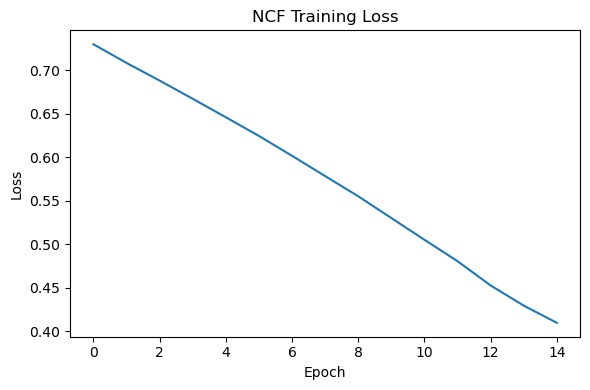

In [34]:
plt.figure(figsize=(6,4))
plt.plot(train_losses)
plt.title("NCF Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [35]:
class ImprovedTwoTower(nn.Module):
    def __init__(self, num_users, num_items, emb_dim=128):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)

        self.user_proj = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

        self.item_proj = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

    def forward(self, user_idx, item_idx):
        u = self.user_emb(user_idx)
        i = self.item_emb(item_idx)
        u = self.user_proj(u)
        i = self.item_proj(i)
        return (u * i).sum(dim=1)

tt_model = ImprovedTwoTower(num_users, num_items, emb_dim=128).to(device)
criterion_tt = nn.BCEWithLogitsLoss()
optimizer_tt = torch.optim.Adam(tt_model.parameters(), lr=5e-4)

In [36]:
tt_losses = []

epochs = 15
for epoch in range(epochs):
    tt_model.train()
    total_loss = 0.0

    for users_b, items_b, labels_b in train_loader_ncf:
        users_b = users_b.to(device)
        items_b = items_b.to(device)
        labels_b = labels_b.to(device)

        optimizer_tt.zero_grad()
        logits = tt_model(users_b, items_b)
        loss = criterion_tt(logits, labels_b)
        loss.backward()
        optimizer_tt.step()

        total_loss += loss.item() * len(users_b)

    avg_loss = total_loss / len(train_loader_ncf.dataset)
    tt_losses.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{epochs} - loss: {avg_loss:.4f}")

Epoch 01/15 - loss: 0.7395
Epoch 02/15 - loss: 0.6220
Epoch 03/15 - loss: 0.5309
Epoch 04/15 - loss: 0.4622
Epoch 05/15 - loss: 0.4123
Epoch 06/15 - loss: 0.3784
Epoch 07/15 - loss: 0.3574
Epoch 08/15 - loss: 0.3459
Epoch 09/15 - loss: 0.3406
Epoch 10/15 - loss: 0.3381
Epoch 11/15 - loss: 0.3357
Epoch 12/15 - loss: 0.3320
Epoch 13/15 - loss: 0.3260
Epoch 14/15 - loss: 0.3180
Epoch 15/15 - loss: 0.3084


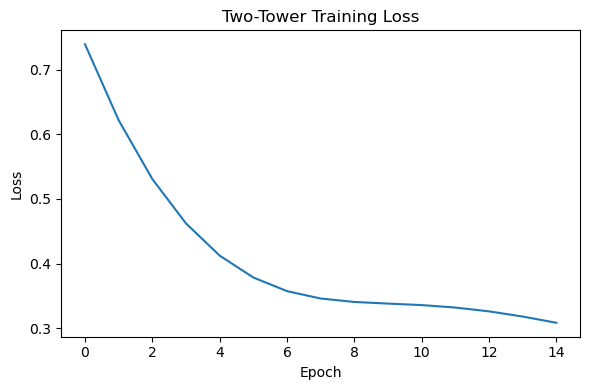

In [37]:
plt.figure(figsize=(6,4))
plt.plot(tt_losses)
plt.title("Two-Tower Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [38]:
def precision_recall_at_k_safe(model, test_pairs, user_train_items, num_items, k=10, num_neg=200):
    model.eval()
    precisions = []
    recalls = []

    all_items = np.arange(num_items)

    with torch.no_grad():
        for u, true_item in tqdm(test_pairs, desc=f"Evaluating @ {k}"):
            seen_items = set(user_train_items[u])
            seen_items.add(true_item)

            available_negatives = np.array([it for it in all_items if it not in seen_items])

            if len(available_negatives) == 0:
                continue

            actual_num_neg = min(num_neg, len(available_negatives))
            sampled_negatives = np.random.choice(
                available_negatives,
                size=actual_num_neg,
                replace=False
            )

            candidates = np.concatenate(([true_item], sampled_negatives))

            user_tensor = torch.tensor([u] * len(candidates), dtype=torch.long).to(device)
            item_tensor = torch.tensor(candidates, dtype=torch.long).to(device)

            scores = torch.sigmoid(model(user_tensor, item_tensor)).cpu().numpy()
            ranked_idx = np.argsort(scores)[::-1]
            ranked_items = candidates[ranked_idx]
            top_k = ranked_items[:k]

            hit = 1 if true_item in top_k else 0
            precisions.append(hit / k)
            recalls.append(hit)

    if len(precisions) == 0:
        return 0.0, 0.0

    return float(np.mean(precisions)), float(np.mean(recalls))

In [39]:
ncf_p10, ncf_r10 = precision_recall_at_k_safe(
    ncf_model, test_pairs, user_train_items, num_items, k=10, num_neg=200
)

tt_p10, tt_r10 = precision_recall_at_k_safe(
    tt_model, test_pairs, user_train_items, num_items, k=10, num_neg=200
)

print(f"NCF Precision@10: {ncf_p10:.4f}")
print(f"NCF Recall@10:    {ncf_r10:.4f}")
print(f"Two-Tower Precision@10: {tt_p10:.4f}")
print(f"Two-Tower Recall@10:    {tt_r10:.4f}")

Evaluating @ 10:   0%|          | 0/81 [00:00<?, ?it/s]

Evaluating @ 10:   0%|          | 0/81 [00:00<?, ?it/s]

NCF Precision@10: 0.0210
NCF Recall@10:    0.2099
Two-Tower Precision@10: 0.0235
Two-Tower Recall@10:    0.2346


In [40]:
final_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Train Loss": round(lr_logloss, 4),
        "Metric": "AUROC",
        "Score": round(baseline_results["Logistic Regression"], 4)
    },
    {
        "Model": "Random Forest",
        "Train Loss": round(rf_logloss, 4),
        "Metric": "AUROC",
        "Score": round(baseline_results["Random Forest"], 4)
    },
    {
        "Model": "ANN / MLP",
        "Train Loss": round(mlp_losses[-1], 4),
        "Metric": "AUROC",
        "Score": round(baseline_results["ANN / MLP"], 4)
    },
    {
        "Model": "LSTM",
        "Train Loss": round(lstm_losses[-1], 4),
        "Metric": "Hit@10",
        "Score": round(lstm_hit10, 4)
    },
    {
        "Model": "NCF",
        "Train Loss": round(train_losses[-1], 4),
        "Metric": "Precision@10 / Recall@10",
        "Score": f"{ncf_p10:.4f} / {ncf_r10:.4f}"
    },
    {
        "Model": "Two-Tower",
        "Train Loss": round(tt_losses[-1], 4),
        "Metric": "Precision@10 / Recall@10",
        "Score": f"{tt_p10:.4f} / {tt_r10:.4f}"
    }
])

final_results

,Model,Train Loss,Metric,Score
0,Logistic Regression,0.6595,AUROC,0.6152
1,Random Forest,0.3131,AUROC,0.7216
2,ANN / MLP,0.2462,AUROC,0.6259
3,LSTM,7.0237,Hit@10,0.0465
4,NCF,0.4100,Precision@10 / Recall@10,0.0210 / 0.2099
5,Two-Tower,0.3084,Precision@10 / Recall@10,0.0235 / 0.2346


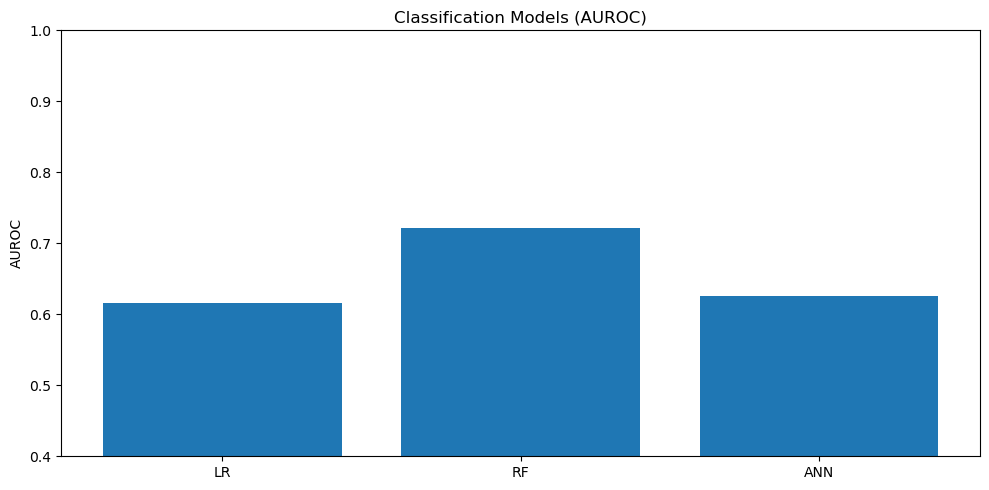

In [41]:
plt.figure(figsize=(10,5))
plt.bar(
    ["LR", "RF", "ANN"],
    [
        baseline_results["Logistic Regression"],
        baseline_results["Random Forest"],
        baseline_results["ANN / MLP"]
    ]
)
plt.title("Classification Models (AUROC)")
plt.ylabel("AUROC")
plt.ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

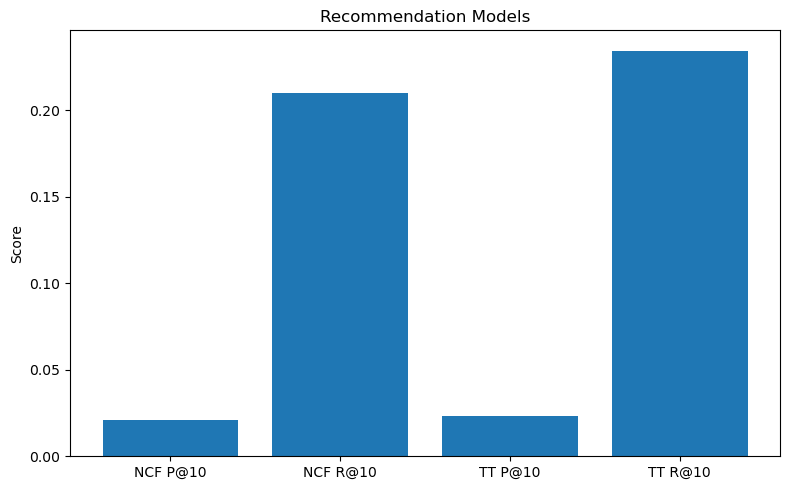

In [42]:
plt.figure(figsize=(8,5))
plt.bar(
    ["NCF P@10", "NCF R@10", "TT P@10", "TT R@10"],
    [ncf_p10, ncf_r10, tt_p10, tt_r10]
)
plt.title("Recommendation Models")
plt.ylabel("Score")
plt.tight_layout()
plt.show()